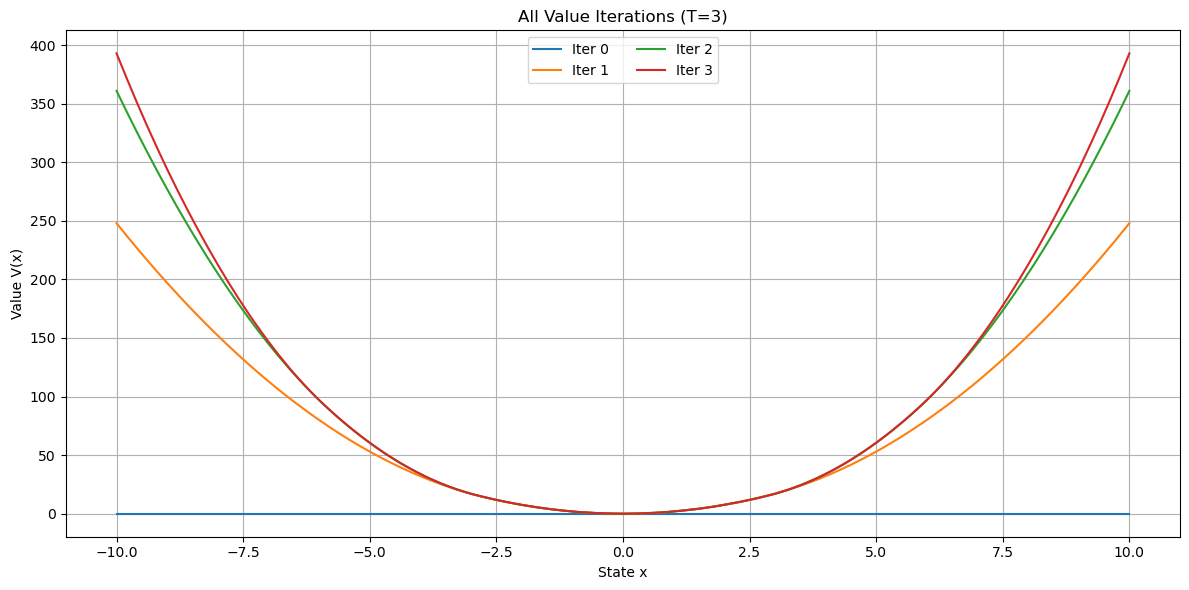

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
x_grid = np.linspace(-10, 10, 201)   # state grid
u_grid = np.linspace(-1, 1, 21)      # control grid
gamma = 1.0                          # no discount
T = 3                                # T-step lookahead
n_iter = 3                          # number of value iterations

# Initialize value function
V = np.zeros_like(x_grid) # For each x state on the grid, there is a corresponding value (V(x)) which corresponds to a cost-to-go estimate.

# System dynamics
def dynamics(x, u):
    return x + u

# Stage cost function
def stage_cost(x, u):
    return x**2 + u**2

# Interpolate V at arbitrary x. discrete to continuous mapping 
def interpolate_V(x, V, x_grid):
    return np.interp(x, x_grid, V, left=1e6, right=1e6)

# T-step Bellman operator
def B_T(V_prev, T):
    V_new = np.zeros_like(V_prev) # create a new array to hold updated values
    for i, x in enumerate(x_grid): # for each state in the grid
        min_cost = np.inf # initialize minimum cost (inf since we are looking for min)
        for u in u_grid: # for each control in the grid
            cost = 0 # initialize cost
            x_t = x    # current state
            for t in range(T): # simulate T steps ahead
                cost += stage_cost(x_t, u)  # stage cost accumulation
                x_t = dynamics(x_t, u)
            cost += interpolate_V(x_t, V_prev, x_grid)  # terminal cost as the last term
            min_cost = min(min_cost, cost) # find minimum cost over all controls
        V_new[i] = min_cost # only keeps the minimum cost over all updates and iterations
    return V_new

# Run value iteration
V_history = [V.copy()]
for k in range(n_iter):
    V = B_T(V, T)
    V_history.append(V.copy())

# Plot all iterations of value function
plt.figure(figsize=(12, 6))
for i, V_i in enumerate(V_history):
    plt.plot(x_grid, V_i, label=f'Iter {i}')
plt.title(f'All Value Iterations (T={T})')
plt.xlabel('State x')
plt.ylabel('Value V(x)')
plt.legend(ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

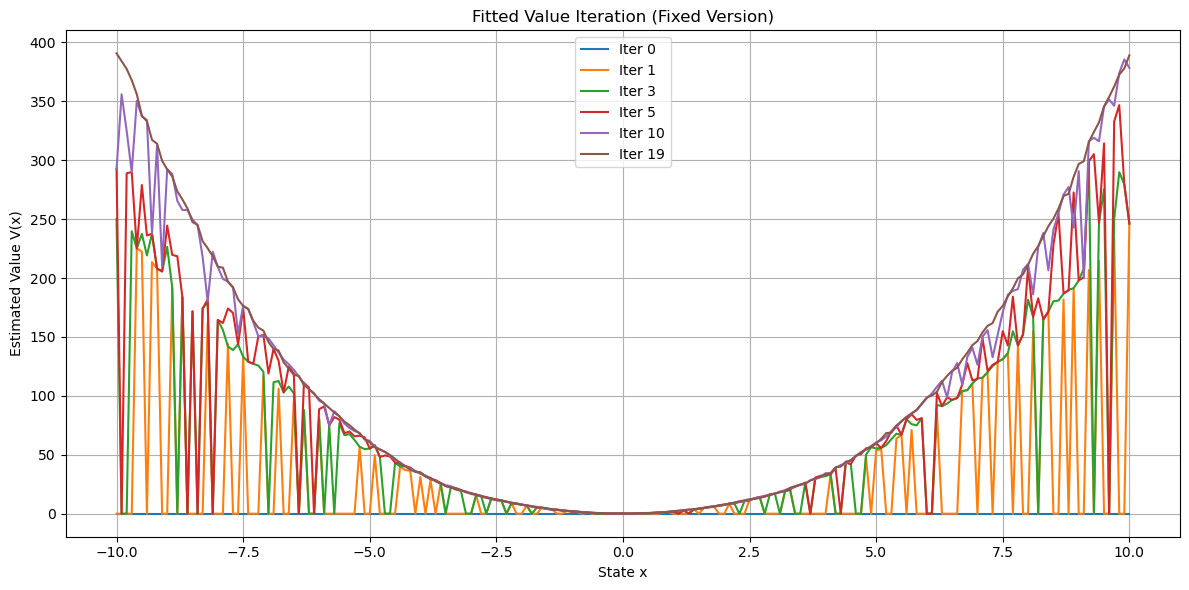

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Define problem parameters
x_grid = np.linspace(-10, 10, 201)
u_grid = np.linspace(-1, 1, 21)
T = 3
n_iter = 20
samples_per_iter = 100

def dynamics(x, u):
    return x + u

def stage_cost(x, u):
    return x**2 + u**2

def interpolate_V(x, V, x_grid):
    return np.interp(x, x_grid, V, left=1e6, right=1e6)

# Initialize value function
V = np.zeros_like(x_grid)
V_history = [V.copy()]

for k in range(n_iter):
    V_new = V.copy() # since not all grid points will be updated due to sampling, we copy the old values
    x_samples = np.random.uniform(-10, 10, samples_per_iter) # sample states uniformly

    for x in x_samples:
        min_cost = float('inf') # initialize minimum cost
        for u in u_grid: # for each control in the grid
            x_t = x     # current state
            cost = 0    # initialize cost
            for t in range(T): # simulate T steps ahead (like MPC)
                cost += stage_cost(x_t, u) # accumulate stage cost
                x_t = dynamics(x_t, u)
            total_cost = cost + interpolate_V(x_t, V, x_grid) # add terminal cost
            min_cost = min(min_cost, total_cost) # find minimum cost over all controls for that one state x

        # Safely interpolate back into grid
        idx = np.argmin(np.abs(x_grid - x))  # closest index
        V_new[idx] = min_cost  # <- Directly assign new value

    V = V_new
    V_history.append(V.copy())

# Plot value function evolution
plt.figure(figsize=(12, 6))
steps = [0, 1, 3, 5, 10, 19]  # show selected iterations
for i in steps:
    plt.plot(x_grid, V_history[i], label=f'Iter {i}')
plt.title('Fitted Value Iteration (Fixed Version)')
plt.xlabel('State x')
plt.ylabel('Estimated Value V(x)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# System setup
x_grid = np.linspace(-10, 10, 201)
u_grid = np.linspace(-1, 1, 21)
T = 3                        # T-step lookahead
n_iter = 20                  # Number of fitted value iterations
samples_per_iter = 200       # Sampled states per iteration

# Dynamics and cost
def dynamics(x, u):
    return x + u

def stage_cost(x, u):
    return x**2 + u**2

# Neural network for V(x)
class ValueNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

# Helpers
def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32).view(-1, 1)

# Initialize NN and optimizer
value_net = ValueNet()
optimizer = optim.Adam(value_net.parameters(), lr=1e-3)
mse_loss = nn.MSELoss()
loss_history = []

# Fitted Value Iteration loop
for k in range(n_iter):
    x_samples = np.random.uniform(-10, 10, size=(samples_per_iter,))
    targets = []

    for x in x_samples:
        min_cost = float('inf')
        for u in u_grid:
            x_t = x
            cost = 0
            for t in range(T):
                cost += stage_cost(x_t, u)
                x_t = dynamics(x_t, u)
            with torch.no_grad():
                v_term = value_net(to_tensor(x_t)).item()
            total_cost = cost + v_term
            min_cost = min(min_cost, total_cost)
        targets.append(min_cost)

    # Train neural net on updated targets
    x_tensor = to_tensor(x_samples)
    y_tensor = to_tensor(targets)

    optimizer.zero_grad()
    preds = value_net(x_tensor)
    loss = mse_loss(preds, y_tensor)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

# Plot final value function
x_plot = np.linspace(-10, 10, 400)
with torch.no_grad():
    V_plot = value_net(to_tensor(x_plot)).squeeze().numpy()

plt.figure(figsize=(10, 6))
plt.plot(x_plot, V_plot, label='Fitted Value Function')
plt.title('Fitted Value Iteration (Neural Network Approximation)')
plt.xlabel('State x')
plt.ylabel('Value V(x)')
plt.grid(True)
plt.legend()
plt.show()

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Training Loss over Iterations")
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()


In [ ]:
# Inputs
# f: dynamics function
# ℓ: cost function
# c: constraint
# T: time horizon
# θ: neural network parameters (weights)
# N: number of VI iterations
# M: number of samples per iteration
# P: number of SGD steps per iteration

# Initialize value function
V = initialize_V1()

# Main value iteration loop
for k in range(1, N + 1):

    # ----- Generate data -----
    dataset = []
    for j in range(1, M + 1): # For each sample
        x_j = sample_x()  # Sample random state
        target_value = B_T(V, x_j)  # This is short horizon MPC with the terminal value approximator?
        dataset.append((x_j, target_value))

    # ----- Fit value function with SGD -----
    for j in range(1, P + 1):
        batch = sample_batch(dataset)
        gradient_descent_step(θ, batch)  # Apply SGD using loss from equation (10)

    # Update value function
    V = update_value_function(θ)

# Output final value function
return V
